In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [3]:
import torch
import torchvision
tf = torchvision.transforms.ToTensor()
nm = torchvision.transforms.Normalize(mean=[0.5], std=[0.5])
from pathlib import Path
from tqdm import tqdm
import PIL
import yaml
from omegaconf import OmegaConf

from rqvae.models.rqvae.rqvae import RQVAE
from rqvae.utils.config import load_config, augment_arch_defaults
from rqvae.models import create_model


In [9]:
model_path = Path("logs/unirqvae3_f16_c1024_k4/ls-rqvae-4x4x4_1024_unshared_2x4090_noattn_zeuslpips__yolo_crops_w_zeus_lpips_white_thresh/20022025_083906/epoch61_model.pt")

config_path = Path("logs/unirqvae3_f16_c1024_k4/ls-rqvae-4x4x4_1024_unshared_2x4090_noattn_zeuslpips__yolo_crops_w_zeus_lpips_white_thresh/20022025_083906/config.yaml")
config = OmegaConf.load(config_path)


In [10]:
config = load_config(config_path)
config.arch = augment_arch_defaults(config.arch)

In [12]:
model, _ = create_model(config.arch)
model.load_state_dict(torch.load(model_path)["state_dict"])
model.eval()
model = model.cuda()


Working with z of shape (1, 256, 16, 16) = 65536 dimensions.


/tmp/ipykernel_1941359/393742582.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path)["state_dict"])


In [38]:
# pt = torch.load("/home/sake/userdata/yt_crawl_updated_0119_tokens/5Utjb6FOHdM/image_tokens/unirqvae_f16_c1024_k4/yolo_shifted/5Utjb6FOHdM:0006:4544_2.pt")

pt = torch.load("/home/sake/userdata/latent_score_dataset_yolo_resize/0-2/segments/_1hjtTo2w1c/image_tokens/unirqvae3_f16_c1024_k4/yolo_shifted/_1hjtTo2w1c:0001:227_0.pt")
pt.shape

/tmp/ipykernel_1941359/1284495980.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pt = torch.load("/home/sake/userdata/latent_score_dataset_yolo_resize/0-2/segments/_1hj

torch.Size([8, 4, 9, 31, 4])

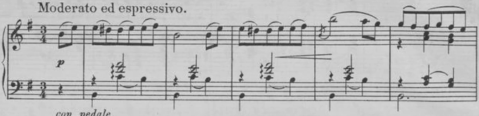

In [54]:
img = PIL.Image.open("/home/sake/userdata/latent_score_dataset_yolo_resize/0-2/segments/_1hjtTo2w1c/images/crop_resized/_1hjtTo2w1c:0001:227_0.png").convert("L")
img

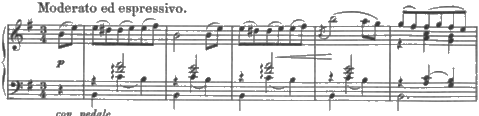

In [55]:
import numpy as np
img_array = np.array(img)
median = np.median(img_array)

# Create binary mask where pixels > (median-20) are 255, others unchanged
img_array[img_array > (median-20)] = 255
img = PIL.Image.fromarray(img_array)
img


torch.Size([1, 7, 30, 4])


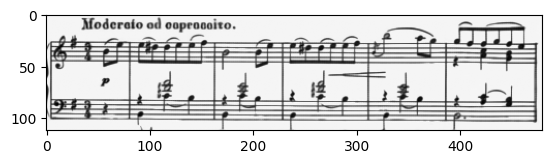

In [71]:
image = tf(img)
image = nm(image)
w_pad = image.shape[-1] % 16
h_pad = image.shape[-2] % 16
# image = torch.nn.functional.pad(image, (0, w_pad, 0, h_pad), mode='constant', value=1)
image = torch.nn.functional.pad(image, (4, 3+w_pad, 2, 1+h_pad), mode='constant', value=1)
image = image[:,:,7:]
out = model.get_codes(image.unsqueeze(0).cuda())
print(out.shape)
decoded = model.decode_code(out)
decoded.shape
import matplotlib.pyplot as plt
plt.imshow(decoded.squeeze(0).squeeze(0).cpu().numpy(), cmap='gray')
plt.show()



In [39]:
decoded = model.decode_code(pt[0,0:1].to(torch.int64).cuda())
decoded.shape

torch.Size([1, 1, 144, 496])

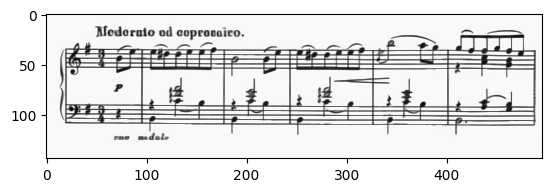

In [40]:
import matplotlib.pyplot as plt
plt.imshow(decoded.squeeze(0).squeeze(0).cpu().numpy(), cmap='gray')
plt.show()

In [41]:
decoded = model.decode_code(pt[0,0:1,1:-1,1:-1].to(torch.int64).cuda())
decoded.shape

torch.Size([1, 1, 112, 464])

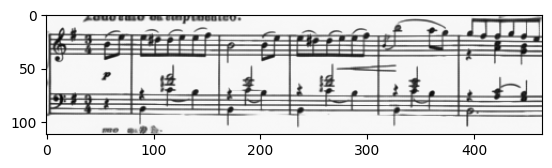

In [42]:
import matplotlib.pyplot as plt
plt.imshow(decoded.squeeze(0).squeeze(0).cpu().numpy(), cmap='gray')
plt.show()

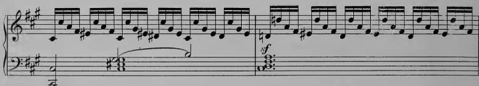

In [21]:
image = PIL.Image.open("/home/sake/userdata/latent_score_dataset_yolo_resize/0-2_1/segments/GiJlj-J0NYU/images/crop_resized/GiJlj-J0NYU:0006:2514_0.png").convert("L")
image

In [24]:
import numpy as np
# Convert PIL image to numpy array
img_array = np.array(image)

# Get median value
median = np.median(img_array)

# Create binary mask where pixels > (median-20) are 255, others unchanged
img_array[img_array > (median-20)] = 255

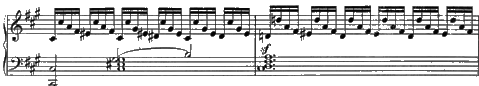

In [25]:
image = PIL.Image.fromarray(img_array)
image

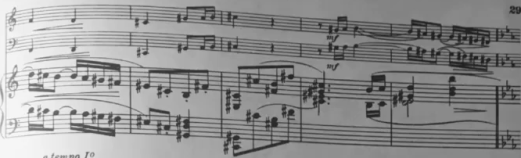

In [4]:
import matplotlib.pyplot as plt
import PIL
import numpy as np
image = PIL.Image.open("/home/sake/userdata/latent_score_dataset_yolo_resize/2-2/segments/rXdsHO5MAbw/images/crop_resized/rXdsHO5MAbw:0054:33673_0.png").convert("L")
image

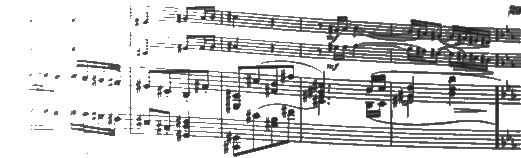

In [5]:

img_array = np.array(image)

# Get median value
median = np.median(img_array)

# Create binary mask where pixels > (median-20) are 255, others unchanged
img_array[img_array > (median-20)] = 255
image = PIL.Image.fromarray(img_array)
image

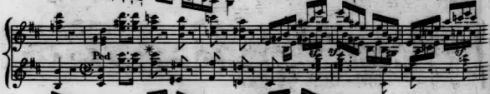

In [1]:
import matplotlib.pyplot as plt
import PIL
import numpy as np
image = PIL.Image.open("/home/sake/userdata/latent_score_dataset_yolo_resize/4-2/segments/pFsMHDfQQng/images/crop_resized/pFsMHDfQQng:0039:31310_2.png").convert("L")
image

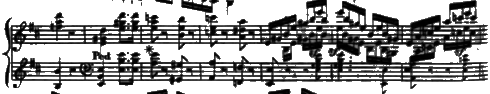

In [2]:
img_array = np.array(image)

# Get median value
median = np.median(img_array)

# Create binary mask where pixels > (median-20) are 255, others unchanged
img_array[img_array > (median-20)] = 255
image = PIL.Image.fromarray(img_array)
image

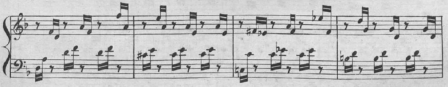

In [1]:
import matplotlib.pyplot as plt
import PIL
import numpy as np
image = PIL.Image.open("/home/sake/userdata/latent_score_dataset_yolo_resize/0-2_1/segments/gUzcT6cIzXk/images/crop_resized/gUzcT6cIzXk:0046:20213_0.png").convert("L")
image

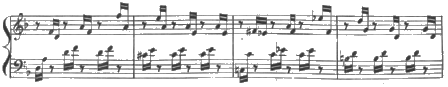

In [2]:
img_array = np.array(image)

# Get median value
median = np.median(img_array)

# Create binary mask where pixels > (median-20) are 255, others unchanged
img_array[img_array > (median-20)] = 255
image = PIL.Image.fromarray(img_array)
image

In [26]:
image.getextrema()

(0, 255)

In [19]:
image = tf(image)
image.shape


torch.Size([1, 86, 479])

In [20]:
image.min(), image.max()

(tensor(0.), tensor(0.8000))

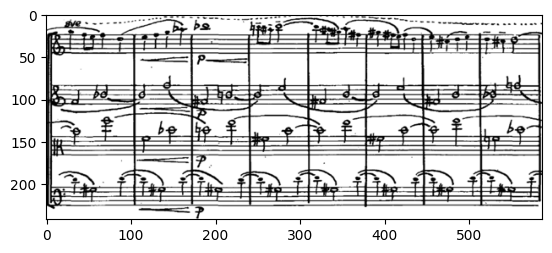

In [10]:
from matplotlib import pyplot as plt
img = PIL.Image.open("/home/sake/userdata/latent_score_dataset_resize/4-0/segments/G8PpBjKCyQs/images/crop_resized/G8PpBjKCyQs:0031:12095_0.png")
plt.imshow(img, cmap='gray')
plt.show()

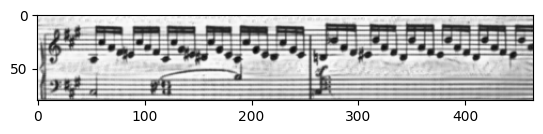

In [14]:
from matplotlib import pyplot as plt
decoded = model.decode_code(pt[0,0:1])
decoded.shape

plt.imshow(decoded.squeeze(0).squeeze(0).cpu().numpy(), cmap='gray')
plt.show()


In [9]:
# img_paths = list(Path("/home/sake/userdata/olimpic_dataset/grandstaff-lmx").rglob("**/*_128.jpg"))

In [18]:
image = PIL.Image.open(img_path)

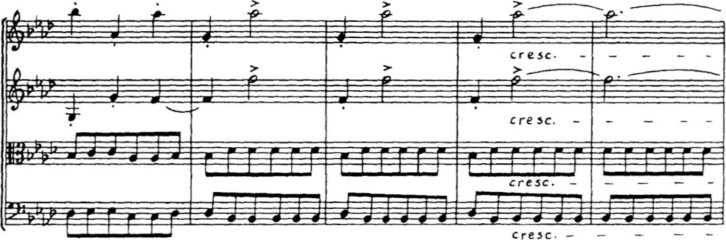

In [19]:
image

In [22]:
image = tf(image)
image = nm(image)
image
image.shape

torch.Size([1, 240, 726])

In [23]:
out = model.get_codes(image.unsqueeze(0).cuda())
out.shape


torch.Size([1, 15, 45, 4])

In [44]:
decoded = model.decode_code(out)
decoded.shape

torch.Size([1, 1, 128, 320])

In [46]:
import cv2

cv2.imwrite(str("temp.png"), (decoded*255).squeeze(0).squeeze(0).cpu().numpy())

True

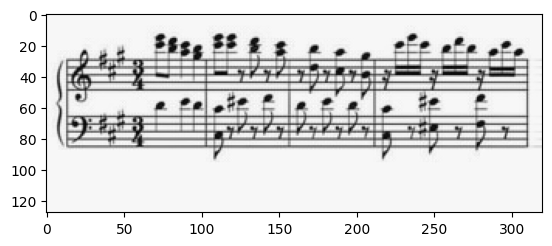

In [39]:
import matplotlib.pyplot as plt
plt.imshow(decoded.squeeze(0).squeeze(0).cpu().numpy(), cmap='gray')
plt.show()


In [19]:
decoded = model.decode_code(out)
decoded.shape


torch.Size([1, 1, 240, 720])

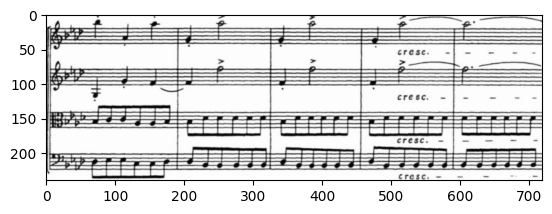

In [21]:
import matplotlib.pyplot as plt
plt.imshow(decoded.cpu().numpy()[0,0,:,:], cmap="gray")
plt.show()


In [12]:
x_y_shifted_toks = []
for i in range(16):
  x_shifted_img = image[...,i:image.shape[-1]-15+i]
  y_shifted_imgs = []
  for j in range(4):
    y_shifted_imgs.append(torch.nn.functional.pad(x_shifted_img[:, j:x_shifted_img.shape[-2]-4+j], (0, 0, 4-j, j), mode='replicate'))
  y_shifted_imgs = torch.stack(y_shifted_imgs)
  out = model.get_codes(y_shifted_imgs.cuda())
  x_y_shifted_toks.append(out.squeeze(0))
x_y_shifted_toks = torch.stack(x_y_shifted_toks)
x_y_shifted_toks.shape


torch.Size([16, 4, 15, 44, 4])

In [30]:
p = list(Path("/home/sake/userdata/olimpic_dataset/grandstaff-lmx/").rglob("**/*.pt"))

In [31]:
p[0]

PosixPath('/home/sake/userdata/olimpic_dataset/grandstaff-lmx/hummel/preludes/prelude67-14/maj3_up_m-7-10:gsocremavq_16_128_gray_unfit_shifted.pt')

In [32]:
loaded = torch.load(p[0])

/tmp/ipykernel_172432/2340646512.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(p[0])


In [33]:
loaded.shape

torch.Size([16, 4, 8, 6])

---